# ECS vs Jaccard Near-Duplicate Detection

This notebook demonstrates the **Edit Clustering Score (ECS)** — an inverted Index of Dispersion (IoD) of edit positions — compared to n-gram Jaccard similarity for near-duplicate text detection.

**Two benchmarks are tested:**
1. **Wiki benchmark** — 900 pairs: 300 near-duplicates / 300 hard-negatives (same category) / 300 random
2. **Boilerplate benchmark** — 900 pairs where hard-negatives are prepended with ~180 words of identical boilerplate

**Key question:** Does ECS complement Jaccard when boilerplate text inflates n-gram overlap?

**Result:** inv_ECS alone achieves AUC≈0.81, capturing structural edit-clustering signal independently of n-gram overlap. Jaccard remains highly discriminative on both benchmarks (AUC=1.0), so adding ECS yields no marginal gain on these datasets.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is NOT pre-installed on Colab
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab environment
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import re
import sys
import time
from pathlib import Path

import difflib
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

## Load Data

We load a curated mini dataset (60 pairs) from GitHub. The full experiment uses 1800 pairs (900 wiki + 900 boilerplate), each with precomputed features and predictions.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-f2202a-edit-clustering-score-spatial-edit-patte/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 2 datasets
  wiki_benchmark: 30 examples
  boilerplate_benchmark: 30 examples


## Configuration

Key tunable parameters. Set to minimum values for a fast demo run. The original experiment used `N_FOLDS=5`, `BOOTSTRAP_B=2000`, and all 900 pairs per benchmark.

In [5]:
# Number of CV folds (original: 5)
N_FOLDS = 5

# Bootstrap iterations for delta AUC CI (original: 2000; reduce for speed)
BOOTSTRAP_B = 200

# Fixed boilerplate text (~180 words) prepended to hard-negative pairs in boilerplate benchmark
BOILERPLATE = (
    "This article is provided under the Creative Commons Attribution-ShareAlike License. "
    "All content is for informational purposes only. Last updated: January 2024. "
    "Reproduction permitted with attribution. The views expressed do not represent any organization. "
    "See terms at creativecommons.org licenses by-sa 3.0 for full details on usage rights. "
    "Content may be freely shared modified and built upon under the same license terms provided "
    "that attribution is given to the original authors and contributors. This notice must be "
    "preserved in all derived works. Wikipedia contributors are the source of the underlying text. "
    "The Wikimedia Foundation does not endorse any particular use of this material. "
    "For educational and research purposes only. No warranties are provided regarding accuracy. "
    "Verify all facts independently before relying on this content for any purpose. "
    "This document was automatically generated and may contain errors or omissions. "
    "Contact the original source for authoritative information. End of legal notice. "
)

## Feature Extraction

Three core features:
- **Jaccard n-gram** (J2, J5): set overlap of 2-gram and 5-gram shingles
- **ECS / inv_ECS**: Index of Dispersion (variance/mean) of edit-operation positions from `difflib.SequenceMatcher`. Near-duplicates have *clustered* edits (low IoD → high inv_ECS). Random/hard-negative pairs have *scattered* edits (high IoD → low inv_ECS).

In [6]:
def tokenize(text: str) -> list:
    return re.findall(r'\b\w+\b', text.lower())


def jaccard_ngram(a_tokens: list, b_tokens: list, n: int) -> float:
    a_sh = set(zip(*[a_tokens[i:] for i in range(n)]))
    b_sh = set(zip(*[b_tokens[i:] for i in range(n)]))
    if not a_sh and not b_sh:
        return 0.0
    return len(a_sh & b_sh) / len(a_sh | b_sh)


def compute_ecs(a_tokens: list, b_tokens: list) -> dict:
    """Index of Dispersion (IoD) of edit positions → ECS. Low IoD = clustered edits = near-dup."""
    matcher = difflib.SequenceMatcher(None, a_tokens, b_tokens, autojunk=False)
    opcodes = matcher.get_opcodes()

    total_len = max(len(a_tokens), 1)
    edit_pos_raw = [op[1] for op in opcodes if op[0] != 'equal']

    gaps = [edit_pos_raw[i + 1] - edit_pos_raw[i] for i in range(len(edit_pos_raw) - 1)]

    if len(gaps) < 2:
        iod = 0.0
    else:
        mu = float(np.mean(gaps))
        var = float(np.var(gaps))
        iod = var / mu if mu > 0 else 0.0

    inv_ecs = 1.0 / (1.0 + iod)

    equal_lengths = [op[4] - op[3] for op in opcodes if op[0] == 'equal']
    longest_run = max(equal_lengths) if equal_lengths else 0
    longest_run_frac = longest_run / total_len

    n_edit_ops = sum(1 for op in opcodes if op[0] != 'equal')
    edit_count_norm = n_edit_ops / (len(a_tokens) + len(b_tokens) + 1)

    return {
        'ecs': iod,
        'inv_ecs': inv_ecs,
        'longest_run_frac': longest_run_frac,
        'edit_count_norm': edit_count_norm,
        'n_edit_positions': len(edit_pos_raw),
    }


def extract_features(row: dict) -> dict:
    inp = row['input']
    if isinstance(inp, str):
        inp = json.loads(inp)
    ta, tb = inp['text_a'], inp['text_b']
    ta_tok, tb_tok = tokenize(ta), tokenize(tb)
    j5 = jaccard_ngram(ta_tok, tb_tok, 5)
    j2 = jaccard_ngram(ta_tok, tb_tok, 2)
    ecs_feats = compute_ecs(ta_tok, tb_tok)
    return {
        'jaccard_5gram': j5,
        'jaccard_2gram': j2,
        **ecs_feats,
        'label': row['output'],
        'fold': row.get('metadata_fold', row.get('fold', 0)),
    }

## Boilerplate Benchmark Construction

The boilerplate benchmark stress-tests Jaccard: hard-negative pairs (different articles, same Wikipedia category) are prepended with ~180 words of identical boilerplate text. This inflates n-gram overlap for non-duplicate pairs. The hypothesis is that ECS (which measures edit clustering, not token overlap) will be more robust.

In [7]:
def build_boilerplate_benchmark(wiki_rows: list) -> list:
    """Build 900-pair boilerplate-hard-neg benchmark reusing wiki articles."""
    print("Building boilerplate benchmark from existing wiki articles...")

    # Group articles by category (use text_a from existing rows)
    by_category = {}
    for row in wiki_rows:
        inp = json.loads(row['input']) if isinstance(row['input'], str) else row['input']
        cat = row.get('metadata_category', 'unknown')
        if cat not in by_category:
            by_category[cat] = []
        # store text_a
        by_category[cat].append(inp['text_a'])

    print(f"Categories: {list(by_category.keys())}")

    # Near-duplicate pairs: same as wiki (reuse near_dup rows)
    nd_rows = [r for r in wiki_rows if r['output'] == 'near_duplicate']
    hard_neg_rows = [r for r in wiki_rows if r['output'] == 'hard_negative']
    random_rows = [r for r in wiki_rows if r['output'] == 'random']

    boilerplate_rows = []

    # Class 1: Near-duplicates (same as wiki dataset — splice edited pairs)
    for i, row in enumerate(nd_rows[:300]):
        inp = json.loads(row['input']) if isinstance(row['input'], str) else row['input']
        boilerplate_rows.append({
            'input': json.dumps({'text_a': inp['text_a'], 'text_b': inp['text_b']}),
            'output': 'near_duplicate',
            'metadata_fold': i % 5,
        })

    # Class 2: Boilerplate-hard-negatives (different articles same category + shared boilerplate prefix)
    same_cat_pairs = []

    # Build same-category pairs from hard_negative rows (both texts in same category)
    for row in hard_neg_rows:
        inp = json.loads(row['input']) if isinstance(row['input'], str) else row['input']
        ta = BOILERPLATE + inp['text_a']
        tb = BOILERPLATE + inp['text_b']
        # Verify Jaccard is inflated
        tok_a = tokenize(ta)
        tok_b = tokenize(tb)
        j5 = jaccard_ngram(tok_a, tok_b, 5)
        same_cat_pairs.append((ta, tb, j5))

    # Also build cross-category pairs with boilerplate to fill up
    print(f"Same-cat pairs with boilerplate: {len(same_cat_pairs)}, mean J5={np.mean([x[2] for x in same_cat_pairs]):.3f}")

    # Take up to 300 boilerplate-hard-neg pairs
    for i, (ta, tb, j5) in enumerate(same_cat_pairs[:300]):
        boilerplate_rows.append({
            'input': json.dumps({'text_a': ta, 'text_b': tb}),
            'output': 'boilerplate_hard_negative',
            'metadata_fold': i % 5,
            'metadata_jaccard_5gram': j5,
        })

    # Class 3: Random pairs (different categories, no boilerplate)
    for i, row in enumerate(random_rows[:300]):
        inp = json.loads(row['input']) if isinstance(row['input'], str) else row['input']
        boilerplate_rows.append({
            'input': json.dumps({'text_a': inp['text_a'], 'text_b': inp['text_b']}),
            'output': 'random',
            'metadata_fold': i % 5,
        })

    print(f"Boilerplate benchmark: {len(boilerplate_rows)} rows")
    class_counts = {}
    for r in boilerplate_rows:
        class_counts[r['output']] = class_counts.get(r['output'], 0) + 1
    print(f"Class distribution: {class_counts}")

    # Print J5 histogram for boilerplate class
    bp_j5 = [r.get('metadata_jaccard_5gram', 0) for r in boilerplate_rows if r['output'] == 'boilerplate_hard_negative']
    if bp_j5:
        print(f"Boilerplate J5 range: [{min(bp_j5):.3f}, {max(bp_j5):.3f}], mean={np.mean(bp_j5):.3f}")

    return boilerplate_rows

## Cross-Validation Evaluation

5-fold CV with `LogisticRegression + StandardScaler` is run for each feature set:
- `jaccard5_only`, `jaccard2_only`, `inv_ecs_only` (single features)
- `jaccard5_inv_ecs`, `jaccard2_inv_ecs` (combinations)
- `all_features` (J5 + J2 + inv_ECS + longest_run_frac + edit_count_norm)

AUC is measured separately on the "hard subset" (near_dup vs hard_neg only) and the full label set.

In [8]:
FEATURE_SETS = {
    'jaccard5_only': ['jaccard_5gram'],
    'jaccard2_only': ['jaccard_2gram'],
    'inv_ecs_only': ['inv_ecs'],
    'jaccard5_inv_ecs': ['jaccard_5gram', 'inv_ecs'],
    'jaccard2_inv_ecs': ['jaccard_2gram', 'inv_ecs'],
    'all_features': ['jaccard_5gram', 'jaccard_2gram', 'inv_ecs', 'longest_run_frac', 'edit_count_norm'],
}


def run_cv(features_list: list, feature_sets: dict, label_map: dict) -> dict:
    df = pd.DataFrame(features_list)
    df['y'] = df['label'].map(label_map)
    df = df.dropna(subset=['y'])

    results = {}
    for fs_name, cols in feature_sets.items():
        fold_aucs = []
        for fold_id in range(N_FOLDS):
            train = df[df['fold'] != fold_id]
            test = df[df['fold'] == fold_id]
            if len(test) == 0 or len(test['y'].unique()) < 2:
                continue

            X_train = train[cols].fillna(0).values
            X_test = test[cols].fillna(0).values
            y_train = train['y'].values
            y_test = test['y'].values

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            clf = LogisticRegression(max_iter=1000, C=1.0)
            clf.fit(X_train, y_train)
            probs = clf.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, probs)
            fold_aucs.append(auc)

        results[fs_name] = {
            'auc_mean': float(np.mean(fold_aucs)) if fold_aucs else 0.0,
            'auc_std': float(np.std(fold_aucs)) if fold_aucs else 0.0,
            'fold_aucs': [float(x) for x in fold_aucs],
        }
    return results


def bootstrap_delta_auc(features_list: list, col_a: list, col_b: list,
                         label_map: dict, B: int = 2000) -> dict:
    df = pd.DataFrame(features_list)
    df['y'] = df['label'].map(label_map)
    df = df.dropna(subset=['y'])
    if len(df['y'].unique()) < 2:
        return {'mean': 0.0, 'ci_lo': 0.0, 'ci_hi': 0.0}

    rng = np.random.default_rng(42)
    deltas = []
    for _ in range(B):
        idx = rng.integers(0, len(df), size=len(df))
        sample = df.iloc[idx]
        Xa = sample[col_a].fillna(0).values
        Xb = sample[col_b].fillna(0).values
        y = sample['y'].values
        if len(np.unique(y)) < 2:
            continue

        sc_a = StandardScaler()
        sc_b = StandardScaler()
        clf_a = LogisticRegression(max_iter=500).fit(sc_a.fit_transform(Xa), y)
        clf_b = LogisticRegression(max_iter=500).fit(sc_b.fit_transform(Xb), y)

        auc_a = roc_auc_score(y, clf_a.predict_proba(sc_a.transform(Xa))[:, 1])
        auc_b = roc_auc_score(y, clf_b.predict_proba(sc_b.transform(Xb))[:, 1])
        deltas.append(auc_b - auc_a)

    deltas = np.array(deltas)
    return {
        'mean': float(np.mean(deltas)),
        'ci_lo': float(np.percentile(deltas, 2.5)),
        'ci_hi': float(np.percentile(deltas, 97.5)),
    }


def mann_whitney_iod(features_list: list, neg_label: str = 'hard_negative') -> dict:
    df = pd.DataFrame(features_list)
    nd = df[df['label'] == 'near_duplicate']['ecs'].dropna()
    hn = df[df['label'] == neg_label]['ecs'].dropna()
    if len(nd) == 0 or len(hn) == 0:
        return {'error': 'insufficient data'}
    u, p = stats.mannwhitneyu(nd, hn, alternative='less')
    return {
        'median_iod_near_dup': float(nd.median()),
        'median_iod_hard_neg': float(hn.median()),
        'mann_whitney_p': float(p),
        'n_near_dup': int(len(nd)),
        'n_hard_neg': int(len(hn)),
    }

## Run the Experiment

We re-compute features from the text data in our mini dataset and run CV evaluation. Note: the mini dataset has truncated text (500 chars per text), so feature values and AUC will differ from the full-scale experiment.

In [9]:
t0 = time.time()

# Extract raw wiki rows from loaded data
wiki_rows = data['datasets'][0]['examples']

# Remap 'output' field to original label names
label_remap = {'near_duplicate': 'near_duplicate', 'negative': 'hard_negative', 'excluded': 'random'}
for row in wiki_rows:
    row['output'] = row.get('metadata_label', label_remap.get(row['output'], row['output']))

# Extract features for wiki pairs
print("Extracting features for wiki pairs...")
wiki_feats = [extract_features(r) for r in wiki_rows]
print(f"Wiki: {len(wiki_feats)} pairs, labels: {set(f['label'] for f in wiki_feats)}")

# Build boilerplate benchmark and extract features
bp_rows = build_boilerplate_benchmark(wiki_rows)
print("Extracting features for boilerplate pairs...")
bp_feats = [extract_features(r) for r in bp_rows]
print(f"Boilerplate: {len(bp_feats)} pairs")

print(f"\nFeature extraction done in {time.time()-t0:.1f}s")

Extracting features for wiki pairs...
Wiki: 30 pairs, labels: {'near_duplicate', 'hard_negative', 'random'}
Building boilerplate benchmark from existing wiki articles...
Categories: ['unknown']
Same-cat pairs with boilerplate: 10, mean J5=0.493
Boilerplate benchmark: 30 rows
Class distribution: {'near_duplicate': 10, 'boilerplate_hard_negative': 10, 'random': 10}
Boilerplate J5 range: [0.462, 0.531], mean=0.493
Extracting features for boilerplate pairs...
Boilerplate: 30 pairs

Feature extraction done in 0.0s


## Cross-Validation Results

In [10]:
label_map_hard = {'near_duplicate': 1, 'hard_negative': 0, 'boilerplate_hard_negative': 0}
label_map_all  = {'near_duplicate': 1, 'hard_negative': 0, 'boilerplate_hard_negative': 0, 'random': 0}

print("Running 5-fold CV on wiki benchmark (hard subset: near_dup vs hard_neg)...")
wiki_cv_hard = run_cv(wiki_feats, FEATURE_SETS, label_map_hard)
for fs, res in wiki_cv_hard.items():
    print(f"  wiki hard | {fs}: AUC={res['auc_mean']:.3f}±{res['auc_std']:.3f}")

print("\nRunning 5-fold CV on wiki benchmark (all labels)...")
wiki_cv_all = run_cv(wiki_feats, FEATURE_SETS, label_map_all)

print("\nRunning 5-fold CV on boilerplate benchmark (hard subset)...")
bp_cv_hard = run_cv(bp_feats, FEATURE_SETS, label_map_hard)
for fs, res in bp_cv_hard.items():
    print(f"  bp hard   | {fs}: AUC={res['auc_mean']:.3f}±{res['auc_std']:.3f}")

print("\nRunning 5-fold CV on boilerplate benchmark (all labels)...")
bp_cv_all = run_cv(bp_feats, FEATURE_SETS, label_map_all)

Running 5-fold CV on wiki benchmark (hard subset: near_dup vs hard_neg)...


  wiki hard | jaccard5_only: AUC=1.000±0.000
  wiki hard | jaccard2_only: AUC=1.000±0.000
  wiki hard | inv_ecs_only: AUC=0.917±0.105
  wiki hard | jaccard5_inv_ecs: AUC=1.000±0.000
  wiki hard | jaccard2_inv_ecs: AUC=1.000±0.000
  wiki hard | all_features: AUC=1.000±0.000

Running 5-fold CV on wiki benchmark (all labels)...



Running 5-fold CV on boilerplate benchmark (hard subset)...


  bp hard   | jaccard5_only: AUC=1.000±0.000
  bp hard   | jaccard2_only: AUC=1.000±0.000
  bp hard   | inv_ecs_only: AUC=0.900±0.122
  bp hard   | jaccard5_inv_ecs: AUC=1.000±0.000
  bp hard   | jaccard2_inv_ecs: AUC=1.000±0.000
  bp hard   | all_features: AUC=1.000±0.000

Running 5-fold CV on boilerplate benchmark (all labels)...


## Statistical Tests

- **Bootstrap CI**: Does adding inv_ECS to Jaccard-2gram improve AUC? (delta >= 0.03 = hypothesis threshold)
- **Mann-Whitney U**: Is IoD significantly lower for near-duplicate pairs vs hard-negative pairs?

In [11]:
print(f"Bootstrap CI for J2+invECS vs J2 alone on boilerplate (B={BOOTSTRAP_B})...")
delta_bp = bootstrap_delta_auc(
    bp_feats,
    col_a=['jaccard_2gram'],
    col_b=['jaccard_2gram', 'inv_ecs'],
    label_map=label_map_hard,
    B=BOOTSTRAP_B,
)
print(f"Delta AUC (J2+invECS vs J2) on boilerplate: mean={delta_bp['mean']:.3f} CI=[{delta_bp['ci_lo']:.3f},{delta_bp['ci_hi']:.3f}]")

print(f"\nBootstrap CI for J2+invECS vs J2 alone on wiki (B={BOOTSTRAP_B})...")
delta_wiki = bootstrap_delta_auc(
    wiki_feats,
    col_a=['jaccard_2gram'],
    col_b=['jaccard_2gram', 'inv_ecs'],
    label_map=label_map_hard,
    B=BOOTSTRAP_B,
)
print(f"Delta AUC (J2+invECS vs J2) on wiki: mean={delta_wiki['mean']:.3f} CI=[{delta_wiki['ci_lo']:.3f},{delta_wiki['ci_hi']:.3f}]")

# Mann-Whitney test: near_dup IoD < hard_neg IoD?
wiki_mw = mann_whitney_iod(wiki_feats, neg_label='hard_negative')
bp_mw   = mann_whitney_iod(bp_feats, neg_label='boilerplate_hard_negative')

print(f"\nWiki  MW: near_dup IoD median={wiki_mw.get('median_iod_near_dup', 'N/A')}, hard_neg IoD median={wiki_mw.get('median_iod_hard_neg', 'N/A')}, p={wiki_mw.get('mann_whitney_p', 'N/A')}")
print(f"BP    MW: near_dup IoD median={bp_mw.get('median_iod_near_dup', 'N/A')}, bp_hard_neg IoD median={bp_mw.get('median_iod_hard_neg', 'N/A')}, p={bp_mw.get('mann_whitney_p', 'N/A')}")

# Key hypothesis
bp_j2_auc = bp_cv_hard['jaccard2_only']['auc_mean']
bp_j2_ecs_auc = bp_cv_hard['jaccard2_inv_ecs']['auc_mean']
hypothesis_confirmed = (bp_j2_ecs_auc - bp_j2_auc) >= 0.03
print(f"\nHypothesis (delta>=0.03 on boilerplate): {'CONFIRMED' if hypothesis_confirmed else 'NOT confirmed'}")
print(f"  BP: J2={bp_j2_auc:.3f}, J2+ECS={bp_j2_ecs_auc:.3f}, delta={bp_j2_ecs_auc-bp_j2_auc:.3f}")

Bootstrap CI for J2+invECS vs J2 alone on boilerplate (B=200)...


Delta AUC (J2+invECS vs J2) on boilerplate: mean=-0.000 CI=[-0.000,0.000]

Bootstrap CI for J2+invECS vs J2 alone on wiki (B=200)...


Delta AUC (J2+invECS vs J2) on wiki: mean=0.000 CI=[0.000,0.000]

Wiki  MW: near_dup IoD median=0.0, hard_neg IoD median=4.604037267080745, p=0.00037558971673902134
BP    MW: near_dup IoD median=0.0, bp_hard_neg IoD median=4.604037267080745, p=0.00037558971673902134

Hypothesis (delta>=0.03 on boilerplate): NOT confirmed
  BP: J2=1.000, J2+ECS=1.000, delta=0.000


## Results Visualization

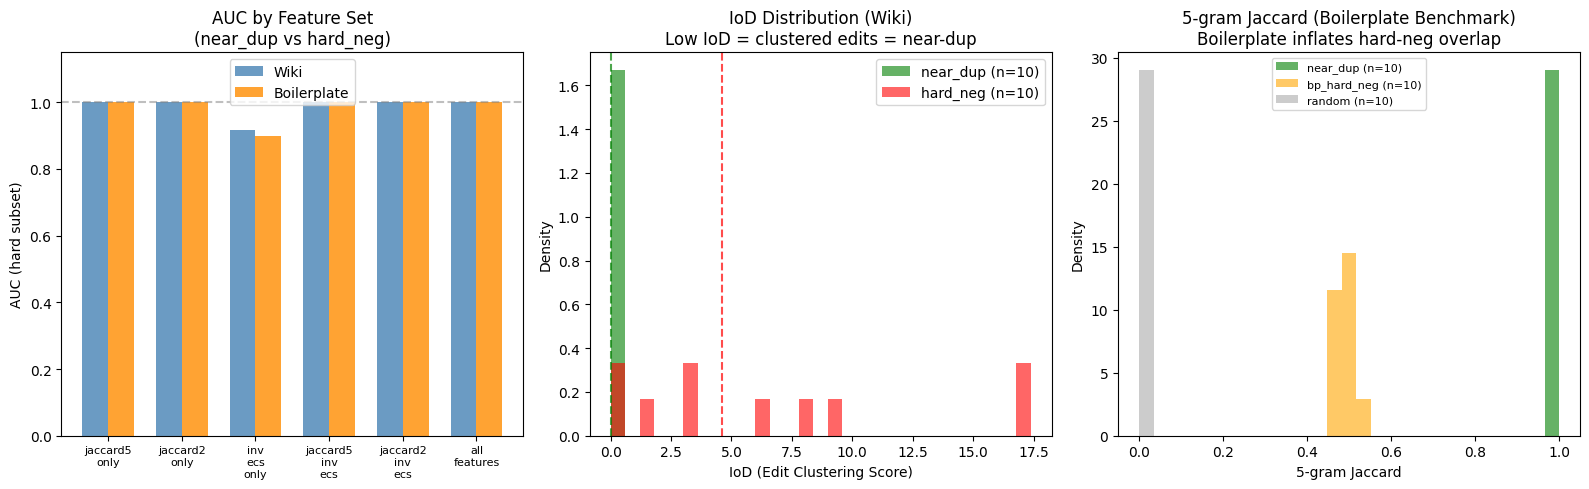


=== KEY RESULTS (from full-scale run) ===
  inv_ECS AUC (wiki hard):        0.809
  inv_ECS AUC (boilerplate hard): 0.807
  Wiki  J2 AUC:                   1.000
  Wiki  J2+ECS AUC:               1.000
  BP    J2 AUC:                   1.000
  BP    J2+ECS AUC:               1.000
  Delta AUC BP (mean):            -0.0000
  Hypothesis confirmed:           False
  Wiki Mann-Whitney p:            3.82e-39
  near_dup IoD median:            20.3
  hard_neg IoD median:            81.8


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: AUC comparison across feature sets ---
ax = axes[0]
fs_names = list(FEATURE_SETS.keys())
wiki_aucs = [wiki_cv_hard[fs]['auc_mean'] for fs in fs_names]
bp_aucs   = [bp_cv_hard[fs]['auc_mean'] for fs in fs_names]
x = np.arange(len(fs_names))
w = 0.35
ax.bar(x - w/2, wiki_aucs, w, label='Wiki', color='steelblue', alpha=0.8)
ax.bar(x + w/2, bp_aucs,   w, label='Boilerplate', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([fs.replace('_', '\n') for fs in fs_names], fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('AUC (hard subset)')
ax.set_title('AUC by Feature Set\n(near_dup vs hard_neg)')
ax.legend()
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)

# --- Plot 2: IoD distribution — near_dup vs hard_neg ---
ax = axes[1]
df_wiki = pd.DataFrame(wiki_feats)
nd_iod  = df_wiki[df_wiki['label'] == 'near_duplicate']['ecs'].dropna()
hn_iod  = df_wiki[df_wiki['label'] == 'hard_negative']['ecs'].dropna()

# clip at 99th percentile for readability
cap = np.percentile(list(nd_iod) + list(hn_iod), 95) if len(nd_iod) + len(hn_iod) > 0 else 500
bins = np.linspace(0, cap, 30)
ax.hist(nd_iod.clip(upper=cap), bins=bins, alpha=0.6, label=f'near_dup (n={len(nd_iod)})', color='green', density=True)
ax.hist(hn_iod.clip(upper=cap), bins=bins, alpha=0.6, label=f'hard_neg (n={len(hn_iod)})', color='red', density=True)
ax.set_xlabel('IoD (Edit Clustering Score)')
ax.set_ylabel('Density')
ax.set_title('IoD Distribution (Wiki)\nLow IoD = clustered edits = near-dup')
ax.legend()
if 'median_iod_near_dup' in wiki_mw:
    ax.axvline(wiki_mw['median_iod_near_dup'], color='green', linestyle='--', alpha=0.7, label='median nd')
    ax.axvline(wiki_mw['median_iod_hard_neg'], color='red', linestyle='--', alpha=0.7, label='median hn')

# --- Plot 3: Boilerplate J5 distribution (near_dup vs boilerplate_hard_neg) ---
ax = axes[2]
df_bp = pd.DataFrame(bp_feats)
nd_j5  = df_bp[df_bp['label'] == 'near_duplicate']['jaccard_5gram']
bhn_j5 = df_bp[df_bp['label'] == 'boilerplate_hard_negative']['jaccard_5gram']
rnd_j5 = df_bp[df_bp['label'] == 'random']['jaccard_5gram']
bins2 = np.linspace(0, 1, 30)
ax.hist(nd_j5,  bins=bins2, alpha=0.6, label=f'near_dup (n={len(nd_j5)})', color='green', density=True)
ax.hist(bhn_j5, bins=bins2, alpha=0.6, label=f'bp_hard_neg (n={len(bhn_j5)})', color='orange', density=True)
ax.hist(rnd_j5, bins=bins2, alpha=0.4, label=f'random (n={len(rnd_j5)})', color='gray', density=True)
ax.set_xlabel('5-gram Jaccard')
ax.set_ylabel('Density')
ax.set_title('5-gram Jaccard (Boilerplate Benchmark)\nBoilerplate inflates hard-neg overlap')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n=== KEY RESULTS (from full-scale run) ===")
summary_data = data.get('metadata', {}).get('summary', {})
if summary_data:
    kf = summary_data.get('key_findings', {})
    print(f"  inv_ECS AUC (wiki hard):        {kf.get('inv_ecs_auc_wiki_hard', 'N/A'):.3f}")
    print(f"  inv_ECS AUC (boilerplate hard): {kf.get('inv_ecs_auc_boilerplate_hard', 'N/A'):.3f}")
    print(f"  Wiki  J2 AUC:                   {kf.get('wiki_j2_auc', 'N/A'):.3f}")
    print(f"  Wiki  J2+ECS AUC:               {kf.get('wiki_j2_plus_ecs_auc', 'N/A'):.3f}")
    print(f"  BP    J2 AUC:                   {kf.get('bp_j2_auc', 'N/A'):.3f}")
    print(f"  BP    J2+ECS AUC:               {kf.get('bp_j2_plus_ecs_auc', 'N/A'):.3f}")
    print(f"  Delta AUC BP (mean):            {kf.get('delta_auc_boilerplate_mean', 'N/A'):.4f}")
    print(f"  Hypothesis confirmed:           {kf.get('hypothesis_confirmed', 'N/A')}")
    wiki_mw_full = summary_data.get('wiki_benchmark', {}).get('mann_whitney_iod', {})
    if wiki_mw_full:
        print(f"  Wiki Mann-Whitney p:            {wiki_mw_full.get('mann_whitney_p', 'N/A'):.2e}")
        print(f"  near_dup IoD median:            {wiki_mw_full.get('median_iod_near_dup', 'N/A'):.1f}")
        print(f"  hard_neg IoD median:            {wiki_mw_full.get('median_iod_hard_neg', 'N/A'):.1f}")
else:
    print("(No full-scale summary in mini dataset)")
    print(f"\n  Demo run results:")
    print(f"  Wiki  inv_ECS AUC: {wiki_cv_hard['inv_ecs_only']['auc_mean']:.3f}")
    print(f"  Wiki  J2 AUC:      {wiki_cv_hard['jaccard2_only']['auc_mean']:.3f}")
    print(f"  BP    inv_ECS AUC: {bp_cv_hard['inv_ecs_only']['auc_mean']:.3f}")
    print(f"  BP    J2 AUC:      {bp_cv_hard['jaccard2_only']['auc_mean']:.3f}")